In [1]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from transformacion import (
    calcular_retornos_simples,
    calcular_retornos_log
)

# 🔄 Retornos simples y logarítmicos

In [16]:
# precios de cierre del portafolio
tickers = ["AAPL", "AMZN", "JPM", "GS", "TSLA"]
inicio = "2021-01-01"
fin = "2024-12-31"

In [12]:
precios = yf.download(
    tickers,
    start=inicio,
    end=fin,
    auto_adjust=True
)["Close"]

print("Precios de cierre:")
print(precios.head())

[*********************100%***********************]  5 of 5 completed

Precios de cierre:
Ticker            AAPL        AMZN          GS         JPM        TSLA
2021-01-04  125.740860  159.331497  233.060959  109.491554  243.256668
2021-01-05  127.295448  160.925507  238.276245  110.087334  245.036667
2021-01-06  123.010513  156.919006  251.134155  115.256577  251.993332
2021-01-07  127.208069  158.108002  256.498993  119.041519  272.013336
2021-01-08  128.306030  159.134995  255.118164  119.172943  293.339996


In [17]:
# retornos diarios simples y logarítmicos
retornos_log = np.log(precios / precios.shift(1)).dropna()

print("\nRetornos simples:")
print(retornos_simples.head())

print("\nRetornos logarítmicos:")
print(retornos_log.head())


Retornos simples:
Ticker          AAPL      AMZN        GS       JPM      TSLA
2021-01-05  0.012363  0.010004  0.022377  0.005441  0.007317
2021-01-06 -0.033661 -0.024897  0.053962  0.046956  0.028390
2021-01-07  0.034124  0.007577  0.021362  0.032839  0.079447
2021-01-08  0.008631  0.006496 -0.005383  0.001104  0.078403
2021-01-11 -0.023249 -0.021519  0.012927  0.014924 -0.078214

Retornos logarítmicos:
Ticker          AAPL      AMZN        GS       JPM      TSLA
2021-01-05  0.012288  0.009955  0.022131  0.005427  0.007291
2021-01-06 -0.034241 -0.025212  0.052557  0.045887  0.027995
2021-01-07  0.033554  0.007549  0.021137  0.032312  0.076448
2021-01-08  0.008594  0.006475 -0.005398  0.001103  0.075481
2021-01-11 -0.023523 -0.021754  0.012845  0.014814 -0.081442


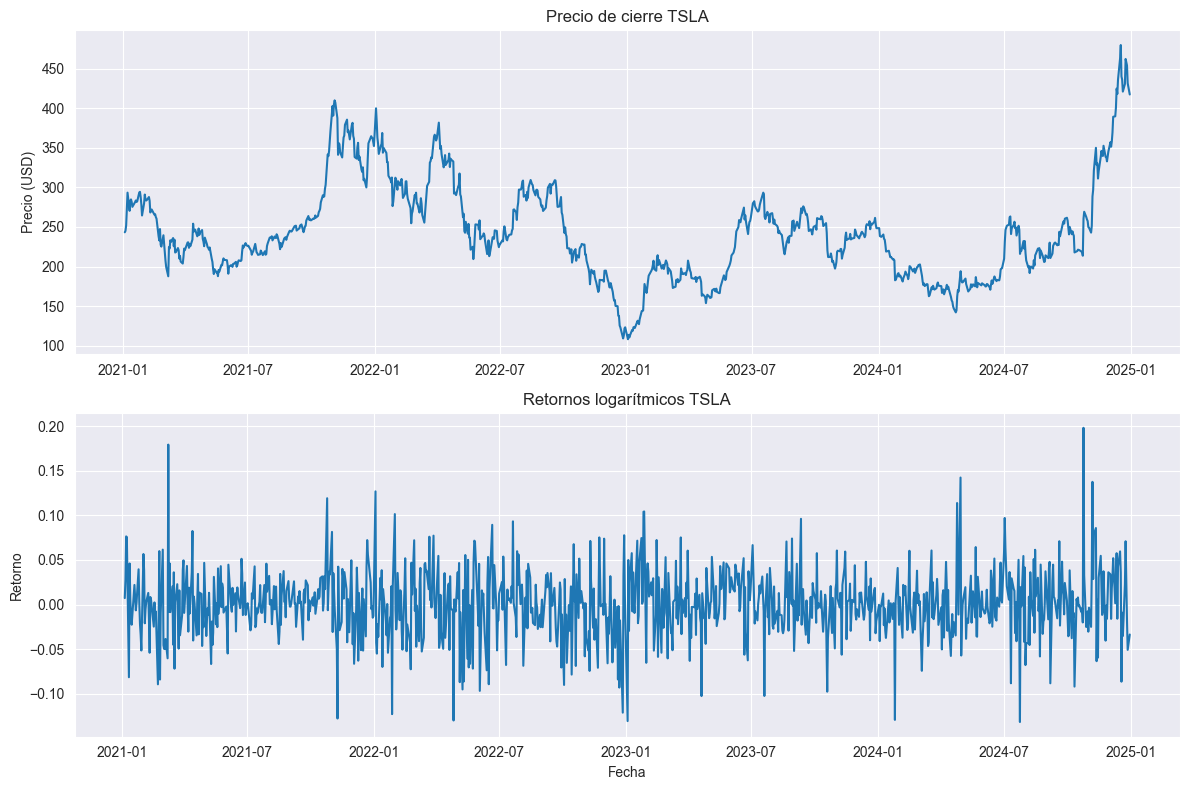

In [18]:
# TSLA
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(precios.index, precios["TSLA"])
axes[0].set_title("Precio de cierre TSLA")
axes[0].set_ylabel("Precio (USD)")
axes[0].grid(True)

axes[1].plot(retornos_log.index, retornos_log["TSLA"])
axes[1].set_title("Retornos logarítmicos TSLA")
axes[1].set_ylabel("Retorno")
axes[1].set_xlabel("Fecha")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Diferencia entre retornos
La principal diferencia es que los retornos simples muestran directamente la variación porcentual entre dos periodos, mientras que los logaritmicos utilizan el logaritmo de la razón entre precios.
Los retornos logaritmicos son más convenientes para analisis financieros porque permiten sumar retornos a través del tiempo y facilitan el uso de modelos estadisticos. Por otra parte, los retornos simples son mas faciles de interpretar para medir ganancias o pérdidas porcentuales.